In [3]:


import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

Final Project Interim Report - Project 1


Reproducing the paper Földiák (1990) sparse coding with anti-Hebbian feedback, experiment 1, figure 2 & 3.

Code done with the help of AI tools.


# 1. parameters

In [45]:

# parameters
@dataclass
class Config:
    # Input image
    grid_size: int = 8              # 8x8 image
    n_units: int = 16               # 16 output/representation units

    # Line distribution
    line_probability: float = 1/8   # each of 8 horizontal + 8 vertical lines drawn independently

    # Network / learning parameters from the paper's Example 1
    alpha: float = 0.1              # anti-Hebbian feedback learning rate
    beta: float = 0.02              # Hebbian feedforward learning rate
    gamma: float = 0.02             # threshold learning rate
    target_activity: float = 1/8    # p, desired output bit probability
    sigmoid_gain: float = 10.0      # lambda in f(u)=1/(1+exp(-lambda*u))

    # Pre-adaptation of thresholds, as described in the Fig. 3 caption
    pretrain_cycles: int = 100
    pretrain_gamma: float = 0.1

    # Main training
    n_trials: int = 2400
    snapshots: tuple = (0, 400, 800, 1200, 2400)

    # Settling dynamics for y*
    settle_steps: int = 80
    dt: float = 0.2
    convergence_tol: float = 1e-5

    # Reproducibility
    seed: int = 7

cfg = Config()

# 2. Pattern generator: combinations of horizontal/vertical lines

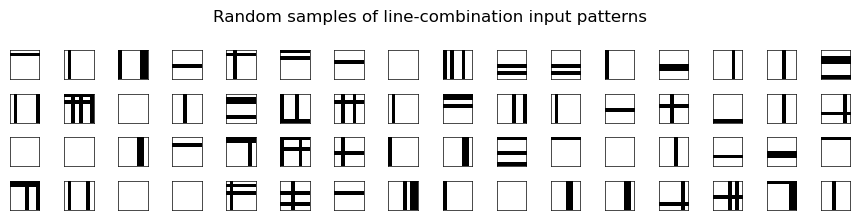

In [46]:
# ============================================================
# 2. Pattern generator: combinations of horizontal/vertical lines
# ============================================================

def make_line_pattern(cfg, rng):
    """
    Generate one 8x8 binary pattern.

    There are 16 possible lines:
      - 8 horizontal rows
      - 8 vertical columns

    Each line is independently drawn with probability cfg.line_probability.
    Pixels belonging to at least one drawn line are set to 1.
    """
    g = cfg.grid_size
    img = np.zeros((g, g), dtype=float)

    horizontal = rng.random(g) < cfg.line_probability
    vertical = rng.random(g) < cfg.line_probability

    img[horizontal, :] = 1.0
    img[:, vertical] = 1.0

    return img.reshape(-1), horizontal, vertical


def show_random_patterns(cfg, n_rows=4, n_cols=16, seed=123):
    """
    Visualize random input patterns, similar to Fig. 2.
    """
    rng = np.random.default_rng(seed)
    patterns = [make_line_pattern(cfg, rng)[0].reshape(cfg.grid_size, cfg.grid_size)
                for _ in range(n_rows * n_cols)]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 0.55, n_rows * 0.55))
    for ax, img in zip(axes.flat, patterns):
        ax.imshow(img, cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)

    plt.suptitle("Random samples of line-combination input patterns")
    plt.tight_layout()
    plt.show()


show_random_patterns(cfg)

The data consists of random draws of any combinations of the 16 lines, reproducing figure 2 in the paper.

# 3. Model

In [47]:
# ============================================================
# 3. The Földiák sparse coding network
# ============================================================

class FoldiakSparseCoder:
    """
    Network architecture:
      x_j : input pixels
      y_i : output / representation units

    State:
      Q[i, j] : feedforward excitatory weight from input j to output unit i
      W[i, j] : inhibitory feedback weight between output units i and j
      t[i]    : threshold of output unit i

    Dynamics:
      dy*/dt = sigmoid(lambda * (Qx + Wy* - t)) - y*

    Output:
      y_i = 1 if y*_i > 0.5 else 0

    Learning:
      Anti-Hebbian feedback:
          ΔW_ij = -alpha * (y_i y_j - p^2)
          W_ii = 0
          W_ij is clipped so it never becomes excitatory, i.e. W_ij <= 0

      Hebbian feedforward:
          ΔQ_ij = beta * y_i * (x_j - Q_ij)

      Threshold:
          Δt_i = gamma * (y_i - p)
    """

    def __init__(self, cfg):
        self.cfg = cfg
        self.rng = np.random.default_rng(cfg.seed)

        m = cfg.grid_size * cfg.grid_size
        n = cfg.n_units

        # Random feedforward weights from U[0,1], normalized per output unit.
        self.Q = self.rng.random((n, m))
        self.Q /= np.linalg.norm(self.Q, axis=1, keepdims=True) + 1e-12

        # Feedback weights initially zero.
        self.W = np.zeros((n, n), dtype=float)

        # Thresholds initially zero. They are pre-adapted before training.
        self.t = np.zeros(n, dtype=float)

    def sigmoid(self, u):
        # Stable sigmoid implementation
        z = np.clip(self.cfg.sigmoid_gain * u, -60, 60)
        return 1.0 / (1.0 + np.exp(-z))

    def settle(self, x):
        """
        Numerically settle the recurrent network for a single input x.
        """
        y_star = np.zeros(self.cfg.n_units, dtype=float)

        for _ in range(self.cfg.settle_steps):
            drive = self.Q @ x + self.W @ y_star - self.t
            y_next = y_star + self.cfg.dt * (self.sigmoid(drive) - y_star)

            if np.max(np.abs(y_next - y_star)) < self.cfg.convergence_tol:
                y_star = y_next
                break

            y_star = y_next

        y_binary = (y_star > 0.5).astype(float)
        return y_star, y_binary

    def update(self, x, y, alpha=None, beta=None, gamma=None):
        """
        Apply one learning update.
        Passing alpha=0 or beta=0 disables that part of learning.
        """
        if alpha is None:
            alpha = self.cfg.alpha
        if beta is None:
            beta = self.cfg.beta
        if gamma is None:
            gamma = self.cfg.gamma

        p = self.cfg.target_activity

        # Anti-Hebbian feedback update
        if alpha != 0:
            self.W += -alpha * (np.outer(y, y) - p**2)

            # Force diagonal to zero and prevent excitatory feedback.
            np.fill_diagonal(self.W, 0.0)
            self.W[self.W > 0] = 0.0

            # Keep symmetry, consistent with the Hopfield-style settling assumption.
            self.W = 0.5 * (self.W + self.W.T)

        # Hebbian feedforward update with decay term
        if beta != 0:
            self.Q += beta * y[:, None] * (x[None, :] - self.Q)

        # Threshold adaptation
        if gamma != 0:
            self.t += gamma * (y - p)

    def pretrain_thresholds(self):
        """
        Before main training, allow thresholds to reach stable values while
        alpha=beta=0 and gamma=0.1, as stated in the paper's Fig. 3 caption.
        """
        for _ in range(self.cfg.pretrain_cycles):
            x, _, _ = make_line_pattern(self.cfg, self.rng)
            _, y = self.settle(x)
            self.update(
                x,
                y,
                alpha=0.0,
                beta=0.0,
                gamma=self.cfg.pretrain_gamma
            )

    def train(self):
        """
        Main training loop.
        Saves Q snapshots at trials listed in cfg.snapshots.
        """
        snapshots = {}

        if 0 in self.cfg.snapshots:
            snapshots[0] = self.Q.copy()

        for trial in range(1, self.cfg.n_trials + 1):
            x, _, _ = make_line_pattern(self.cfg, self.rng)
            _, y = self.settle(x)
            self.update(x, y)

            if trial in self.cfg.snapshots:
                snapshots[trial] = self.Q.copy()

        return snapshots

# 4. Utils

In [48]:
%matplotlib inline

In [49]:
# ============================================================
# 4. Visualization utilities
# ============================================================

def plot_receptive_field_snapshots(snapshots, cfg):
    """
    Visualize feedforward weights Q as 8x8 receptive fields.

    Rows correspond to training time:
      0, 400, 800, 1200 by default.

    Columns correspond to the 16 output units.
    """
    times = list(cfg.snapshots)
    n_times = len(times)
    n_units = cfg.n_units
    g = cfg.grid_size

    fig, axes = plt.subplots(
        n_times,
        n_units,
        figsize=(n_units * 0.65, n_times * 0.85)
    )

    if n_times == 1:
        axes = axes[None, :]

    for row_idx, trial in enumerate(times):
        Q = snapshots[trial]

        # Use a shared range within each row for visual contrast.
        row_min = Q.min()
        row_max = Q.max()

        for unit_idx in range(n_units):
            ax = axes[row_idx, unit_idx]
            rf = Q[unit_idx].reshape(g, g)

            ax.imshow(
                rf,
                cmap="gray_r",
                interpolation="nearest",
                vmin=row_min,
                vmax=row_max
            )
            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(False)

            if unit_idx == 0:
                ax.set_ylabel(str(trial), rotation=0, labelpad=18, va="center")

    plt.suptitle("Feedforward weights of 16 output units over learning trials")
    plt.tight_layout()
    plt.show()


def plot_learned_output_for_sample_patterns(model, cfg, n_patterns=8, seed=999):
    """
    Optional sanity check:
    show some input patterns and their resulting sparse binary code.
    """
    rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(n_patterns, 2, figsize=(4, n_patterns * 1.4))

    for k in range(n_patterns):
        x, _, _ = make_line_pattern(cfg, rng)
        _, y = model.settle(x)

        axes[k, 0].imshow(x.reshape(cfg.grid_size, cfg.grid_size),
                          cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
        axes[k, 0].set_title("input" if k == 0 else "")
        axes[k, 0].set_xticks([])
        axes[k, 0].set_yticks([])

        axes[k, 1].imshow(y.reshape(1, -1),
                          cmap="gray_r", vmin=0, vmax=1, interpolation="nearest",
                          aspect="auto")
        axes[k, 1].set_title("output code" if k == 0 else "")
        axes[k, 1].set_xticks(range(cfg.n_units))
        axes[k, 1].set_yticks([])

    plt.tight_layout()
    plt.show()

In [50]:
# ============================================================
# 4. Visualization utilities
# ============================================================

def plot_receptive_field_snapshots(snapshots, cfg):
    """
    Visualize feedforward weights Q as 8x8 receptive fields.

    Rows correspond to training time:
      0, 400, 800, 1200 by default.

    Columns correspond to the 16 output units.
    """
    times = list(cfg.snapshots)
    n_times = len(times)
    n_units = cfg.n_units
    g = cfg.grid_size

    fig, axes = plt.subplots(
        n_times,
        n_units,
        figsize=(n_units * 0.65, n_times * 0.85)
    )

    if n_times == 1:
        axes = axes[None, :]

    for row_idx, trial in enumerate(times):
        Q = snapshots[trial]

        # Use a shared range within each row for visual contrast.
        row_min = Q.min()
        row_max = Q.max()

        for unit_idx in range(n_units):
            ax = axes[row_idx, unit_idx]
            rf = Q[unit_idx].reshape(g, g)

            ax.imshow(
                rf,
                cmap="gray_r",
                interpolation="nearest",
                vmin=row_min,
                vmax=row_max
            )
            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(False)

            if unit_idx == 0:
                ax.set_ylabel(str(trial), rotation=0, labelpad=18, va="center")

    plt.suptitle("Feedforward weights of 16 output units over learning trials")
    plt.tight_layout()
    plt.show()


def plot_learned_output_for_sample_patterns(model, cfg, n_patterns=8, seed=999):
    """
    Optional sanity check:
    show some input patterns and their resulting sparse binary code.
    """
    rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(n_patterns, 2, figsize=(14, n_patterns * 1.1))

    for k in range(n_patterns):
        x, _, _ = make_line_pattern(cfg, rng)
        _, y = model.settle(x)

        axes[k, 0].imshow(x.reshape(cfg.grid_size, cfg.grid_size),
                          cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
        axes[k, 0].set_title("input" if k == 0 else "")
        axes[k, 0].set_xticks([])
        axes[k, 0].set_yticks([])

        axes[k, 1].imshow(y.reshape(1, -1),
                          cmap="gray_r", vmin=0, vmax=1, interpolation="nearest",
                          aspect="auto")
        axes[k, 1].set_title("output code" if k == 0 else "")
        axes[k, 1].set_xticks(range(cfg.n_units))
        axes[k, 1].set_yticks([])

    plt.tight_layout()
    plt.show()

# 5. Experiment

Pre-adapting thresholds...
Training...
Done.


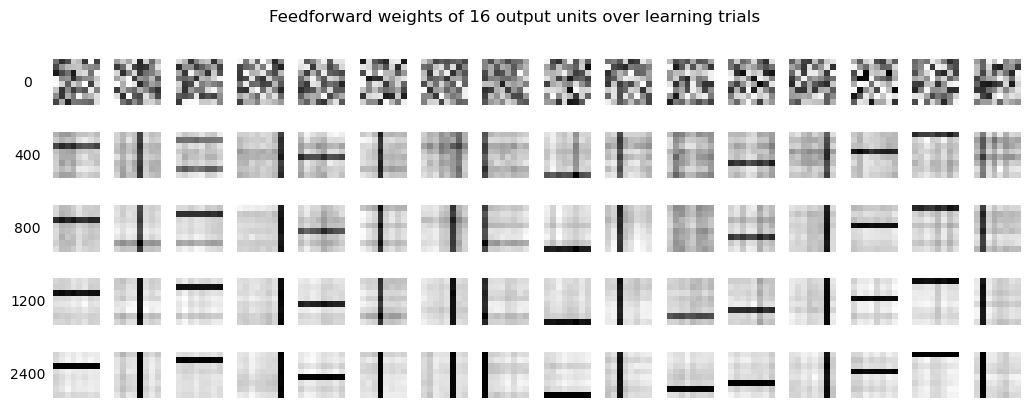

In [52]:
# ============================================================
# 5. Run the experiment
# ============================================================

model = FoldiakSparseCoder(cfg)

print("Pre-adapting thresholds...")
model.pretrain_thresholds()

print("Training...")
snapshots = model.train()

print("Done.")
plot_receptive_field_snapshots(snapshots, cfg)

As can be seen from above, the feedforward connections after training become detectors of the 16 possible lines, reproducing figure 3 of the paper.

We can see that the model decomposes any input signal to the sparse line components, see below. Also, the per-unit activity is roughly constant as 1/8 because it adapts its threshold. The overall activity is very close to the intended sparsity level.

Target activity p:     0.125
Observed mean activity: 0.128
Per-unit activity:
[0.113 0.108 0.133 0.132 0.136 0.112 0.133 0.126 0.131 0.162 0.12  0.13
 0.144 0.11  0.123 0.13 ]


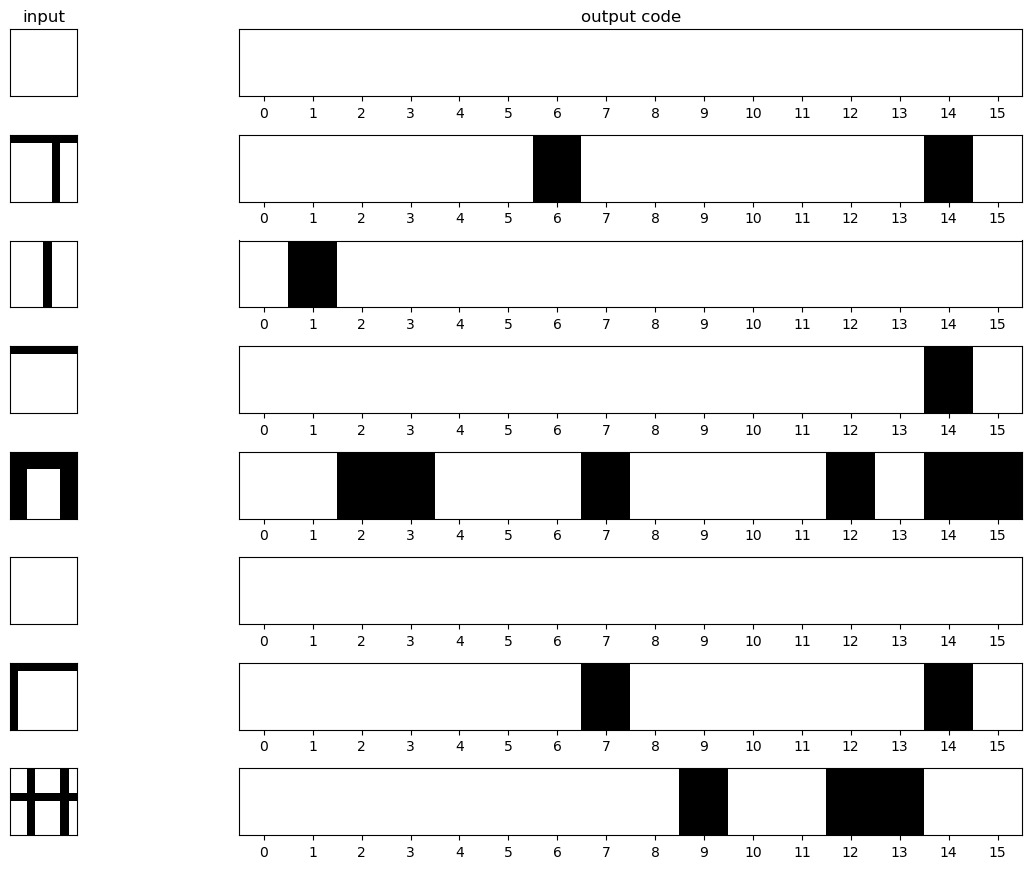

In [54]:


def estimate_activity(model, cfg, n_samples=1000, seed=2024):
    rng = np.random.default_rng(seed)
    outputs = []

    for _ in range(n_samples):
        x, _, _ = make_line_pattern(cfg, rng)
        _, y = model.settle(x)
        outputs.append(y)

    outputs = np.array(outputs)
    mean_activity_per_unit = outputs.mean(axis=0)
    mean_activity_overall = outputs.mean()

    return mean_activity_overall, mean_activity_per_unit


overall, per_unit = estimate_activity(model, cfg)

print(f"Target activity p:     {cfg.target_activity:.3f}")
print(f"Observed mean activity: {overall:.3f}")
print("Per-unit activity:")
print(np.round(per_unit, 3))

plot_learned_output_for_sample_patterns(model, cfg)

# Vary parameters

In [55]:
# ============================================================
# 6. Parameter sweeps
# ============================================================

from dataclasses import replace


def make_cfg(**overrides):
    """Build a Config, auto-setting n_units = 2 * grid_size when grid changes."""
    cfg = Config()
    if "grid_size" in overrides and "n_units" not in overrides:
        overrides = {**overrides, "n_units": 2 * overrides["grid_size"]}
    if "n_trials" in overrides and "snapshots" not in overrides:
        n = overrides["n_trials"]
        overrides = {**overrides, "snapshots": (0, n // 3, 2 * n // 3, n)}
    return replace(cfg, **overrides)


def line_templates(cfg):
    """Binary templates for all horizontal + vertical lines."""
    g = cfg.grid_size
    m = g * g
    templates = []
    labels = []

    for row in range(g):
        t = np.zeros(m, dtype=float)
        t[row * g:(row + 1) * g] = 1.0
        templates.append(t / (np.linalg.norm(t) + 1e-12))
        labels.append(f"H{row}")

    for col in range(g):
        t = np.zeros(m, dtype=float)
        t[col::g] = 1.0
        templates.append(t / (np.linalg.norm(t) + 1e-12))
        labels.append(f"V{col}")

    return np.array(templates), labels


def evaluate_line_selectivity(model, cfg):
    """
    Score how well learned Q rows match the independent line components.
    Returns dict with match score, number of lines recovered, and assignment.
    """
    templates, labels = line_templates(cfg)
    Q = model.Q.copy()
    Q /= np.linalg.norm(Q, axis=1, keepdims=True) + 1e-12

    n_units = cfg.n_units
    n_lines = templates.shape[0]
    corr = Q @ templates.T                          # (n_units, n_lines)
    best_line = corr.argmax(axis=1)
    best_corr = corr.max(axis=1)

    lines_recovered = len(set(best_line))
    mean_match = float(best_corr.mean())

    return {
        "mean_match": mean_match,
        "lines_recovered": lines_recovered,
        "n_lines": n_lines,
        "best_line": best_line,
        "best_corr": best_corr,
        "labels": labels,
    }


def run_foldiak_experiment(cfg, verbose=True):
    """Pretrain thresholds, train, and return model + snapshots + metrics."""
    if verbose:
        print(f"\n--- {cfg.grid_size}x{cfg.grid_size}, p_line={cfg.line_probability:.3f}, "
              f"beta={cfg.beta}, alpha={cfg.alpha}, gamma={cfg.gamma}, n_units={cfg.n_units} ---")

    model = FoldiakSparseCoder(cfg)
    model.pretrain_thresholds()
    snapshots = model.train()

    selectivity = evaluate_line_selectivity(model, cfg)
    overall_act, _ = estimate_activity(model, cfg, seed=cfg.seed + 1000)

    if verbose:
        print(f"  line match score: {selectivity['mean_match']:.3f}")
        print(f"  lines recovered:  {selectivity['lines_recovered']}/{selectivity['n_lines']}")
        print(f"  mean activity:    {overall_act:.3f} (target {cfg.target_activity:.3f})")

    return {
        "cfg": cfg,
        "model": model,
        "snapshots": snapshots,
        "selectivity": selectivity,
        "mean_activity": overall_act,
    }


def plot_final_receptive_fields(result, title=None):
    """Show final Q as receptive fields for one experiment."""
    cfg = result["cfg"]
    Q = result["snapshots"].get(cfg.n_trials, result["model"].Q)
    g = cfg.grid_size
    n_units = cfg.n_units
    n_cols = min(16, n_units)
    n_rows = int(np.ceil(n_units / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 0.65, n_rows * 0.85))
    axes = np.atleast_2d(axes)

    row_min, row_max = Q.min(), Q.max()
    for idx in range(n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        ax = axes[r, c]
        if idx < n_units:
            ax.imshow(Q[idx].reshape(g, g), cmap="gray_r", interpolation="nearest",
                      vmin=row_min, vmax=row_max)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    for idx in range(n_units, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r, c].axis("off")

    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# --- Define conditions to compare ---
experiments = {
    # Input statistics & scale
    "baseline (p=1/8)": make_cfg(),
    "higher line prob (p=1/4)": make_cfg(line_probability=1/4),
    "very dense inputs (p=1/2)": make_cfg(line_probability=1/2),
    "16x16 images (32 units)": make_cfg(grid_size=16),
    "16x16 + 3000 steps": make_cfg(grid_size=16, n_trials=3000),
    "16x16 + 5000 steps": make_cfg(grid_size=16, n_trials=5000),

    # Hebbian feedforward rate beta (default 0.02)
    "lower Hebbian rate (beta=0.005)": make_cfg(beta=0.005),
    "higher Hebbian rate (beta=0.08)": make_cfg(beta=0.08),
    "very high Hebbian rate (beta=0.15)": make_cfg(beta=0.15),

    # Anti-Hebbian lateral rate alpha (default 0.1)
    "lower anti-Hebbian (alpha=0.025)": make_cfg(alpha=0.025),
    "higher anti-Hebbian (alpha=0.4)": make_cfg(alpha=0.4),
    "very high anti-Hebbian (alpha=0.8)": make_cfg(alpha=0.8),

    # Threshold adaptation rate gamma (default 0.02)
    "lower threshold rate (gamma=0.005)": make_cfg(gamma=0.005),
    "higher threshold rate (gamma=0.08)": make_cfg(gamma=0.08),

    # Combined learning-rate changes
    "fast Hebbian + anti-Hebbian": make_cfg(beta=0.08, alpha=0.4),
    "slow Hebbian + anti-Hebbian": make_cfg(beta=0.005, alpha=0.025),
}

results = {}
for name, cfg in experiments.items():
    results[name] = run_foldiak_experiment(cfg)

print("\n" + "=" * 80)
print(f"{'Condition':<42} {'Match':>8} {'Lines':>10} {'Activity':>10}")
print("-" * 80)
for name, res in results.items():
    sel = res["selectivity"]
    print(f"{name:<42} {sel['mean_match']:>8.3f} "
          f"{sel['lines_recovered']:>4}/{sel['n_lines']:<5} {res['mean_activity']:>10.3f}")
print("=" * 80)


--- 8x8, p_line=0.125, beta=0.02, alpha=0.1, gamma=0.02, n_units=16 ---
  line match score: 0.841
  lines recovered:  16/16
  mean activity:    0.127 (target 0.125)

--- 8x8, p_line=0.250, beta=0.02, alpha=0.1, gamma=0.02, n_units=16 ---
  line match score: 0.665
  lines recovered:  15/16
  mean activity:    0.141 (target 0.125)

--- 8x8, p_line=0.500, beta=0.02, alpha=0.1, gamma=0.02, n_units=16 ---
  line match score: 0.402
  lines recovered:  10/16
  mean activity:    0.065 (target 0.125)

--- 16x16, p_line=0.125, beta=0.02, alpha=0.1, gamma=0.02, n_units=32 ---
  line match score: 0.692
  lines recovered:  31/32
  mean activity:    0.128 (target 0.125)

--- 16x16, p_line=0.125, beta=0.02, alpha=0.1, gamma=0.02, n_units=32 ---
  line match score: 0.710
  lines recovered:  31/32
  mean activity:    0.128 (target 0.125)

--- 16x16, p_line=0.125, beta=0.02, alpha=0.1, gamma=0.02, n_units=32 ---
  line match score: 0.731
  lines recovered:  32/32
  mean activity:    0.124 (target 0.125

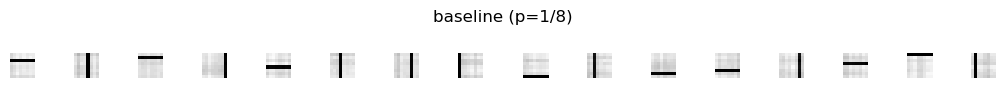

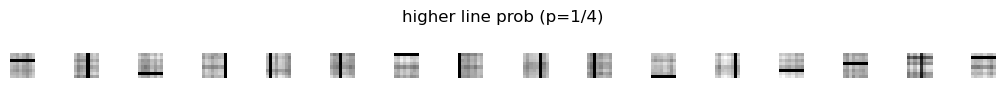

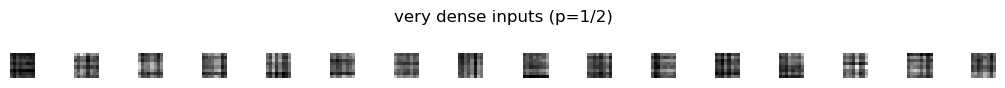

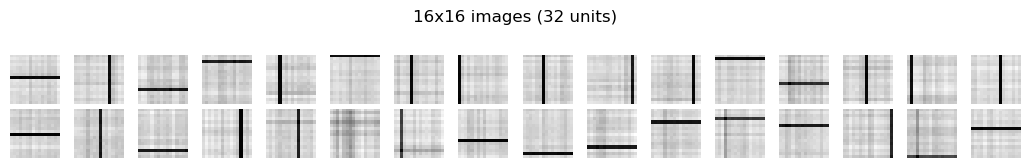

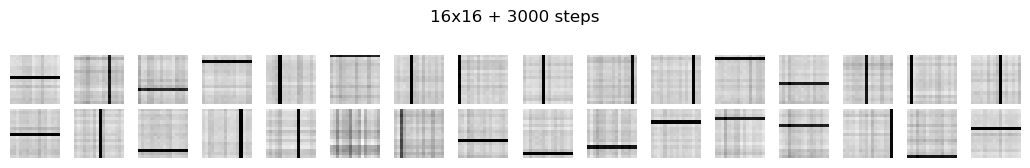

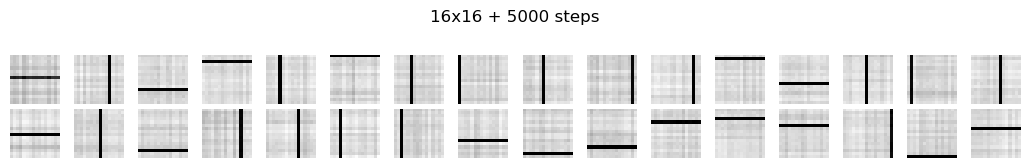

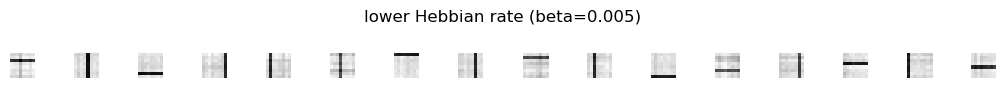

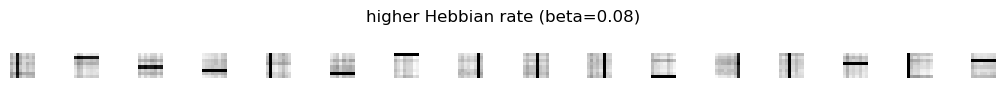

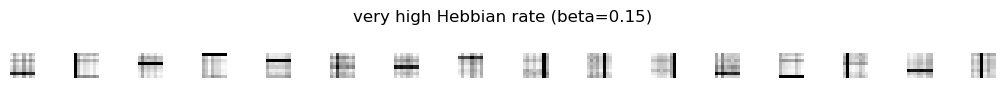

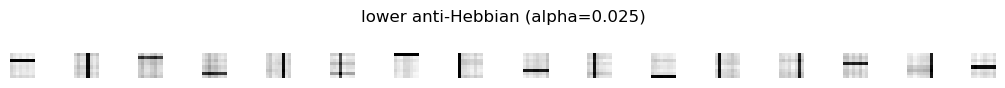

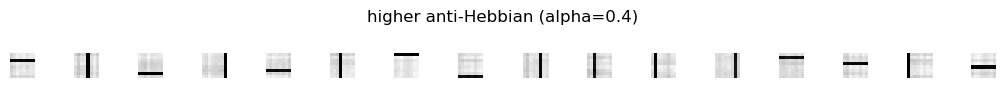

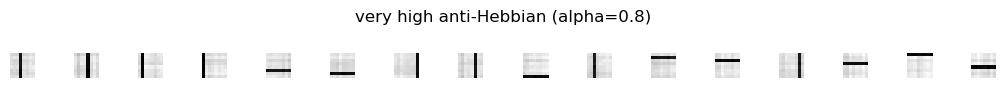

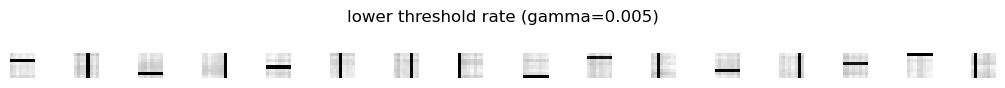

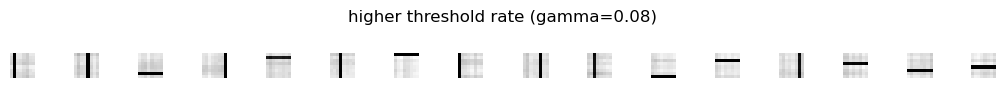

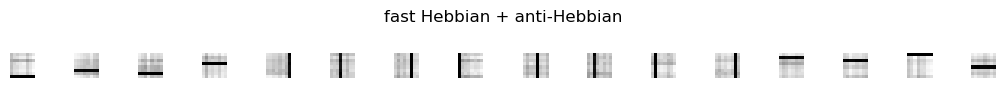

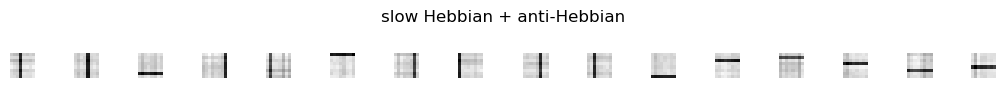

In [56]:
# Visualize final receptive fields for each condition
for name, res in results.items():
    plot_final_receptive_fields(res, title=name)

# MNIST

In [34]:
# ============================================================
# 7. MNIST — load data and training helpers
# ============================================================

import gzip
import pickle
import urllib.request
from pathlib import Path
from dataclasses import replace
from sklearn.linear_model import LogisticRegression

MNIST_PATH = Path("mnist.pkl.gz")
MNIST_URL = "https://s3.amazonaws.com/img-datasets/mnist.pkl.gz"
MNIST_TRAIN_SUBSET = 60000   # unsupervised training subset (speed vs. statistics)
MNIST_N_TRIALS = 50000        # main Foldiak training length on MNIST
MNIST_N_TRIALS_SWEEP = 10000  # shorter runs for parameter sweeps


def download_mnist(path=MNIST_PATH, url=MNIST_URL):
    path = Path(path)
    if path.exists():
        return path
    print(f"Downloading MNIST to {path.resolve()} ...")
    urllib.request.urlretrieve(url, path)
    return path


def load_mnist(path=MNIST_PATH):
    download_mnist(path)
    with gzip.open(path, "rb") as f:
        (x_train, y_train), (x_test, y_test) = pickle.load(f, encoding="latin1")
    return x_train, y_train, x_test, y_test


def downsample_images(images, grid_size, src_size=28):
    """Average-pool 28×28 MNIST images to grid_size×grid_size, return flat [0, 1] vectors."""
    images = np.asarray(images)
    n = images.shape[0]
    if grid_size == src_size:
        return images.reshape(n, -1).astype(float) / 255.0

    pooled = np.zeros((n, grid_size, grid_size), dtype=float)
    for i in range(grid_size):
        for j in range(grid_size):
            r0, r1 = int(i * src_size / grid_size), int((i + 1) * src_size / grid_size)
            c0, c1 = int(j * src_size / grid_size), int((j + 1) * src_size / grid_size)
            pooled[:, i, j] = images[:, r0:r1, c0:c1].mean(axis=(1, 2))
    return pooled.reshape(n, -1) / 255.0


def make_mnist_cfg(grid_size, n_units, n_trials=MNIST_N_TRIALS, seed=11, **overrides):
    """Config for MNIST: grid_size sets input resolution; n_units is independent of grid_size."""
    base = replace(
        Config(),
        grid_size=grid_size,
        n_units=n_units,
        n_trials=n_trials,
        snapshots=(0, n_trials // 3, 2 * n_trials // 3, n_trials),
        seed=seed,
    )
    return replace(base, **overrides)


def pretrain_on_data(model, X):
    for _ in range(model.cfg.pretrain_cycles):
        x = X[model.rng.integers(len(X))]
        _, y = model.settle(x)
        model.update(x, y, alpha=0.0, beta=0.0, gamma=model.cfg.pretrain_gamma)


def train_on_data(model, X):
    """Main Foldiak learning using random samples from X instead of synthetic line patterns."""
    snapshots = {}
    if 0 in model.cfg.snapshots:
        snapshots[0] = model.Q.copy()

    idx = model.rng.integers(0, len(X), size=model.cfg.n_trials)
    for trial, sample_idx in enumerate(idx, start=1):
        x = X[sample_idx]
        _, y = model.settle(x)
        model.update(x, y)
        if trial in model.cfg.snapshots:
            snapshots[trial] = model.Q.copy()
    return snapshots


def encode_dataset(model, X, max_samples=None):
    if max_samples is not None:
        X = X[:max_samples]
    codes = np.zeros((len(X), model.cfg.n_units), dtype=float)
    for i, x in enumerate(X):
        _, codes[i] = model.settle(x)
    return codes


def measure_sparsity(model, X, n_samples=2000, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=min(n_samples, len(X)), replace=False)
    Y = encode_dataset(model, X[idx])
    active_per_sample = Y.sum(axis=1)
    return {
        "mean_bit_activity": float(Y.mean()),
        "target_activity": model.cfg.target_activity,
        "active_units_per_sample": float(active_per_sample.mean()),
        "max_active_units": int(active_per_sample.max()),
        "fraction_silent_samples": float((active_per_sample == 0).mean()),
        "per_unit_rate": Y.mean(axis=0),
    }


def run_mnist_foldiak(X_train, cfg, verbose=True):
    if verbose:
        print(f"Training {cfg.grid_size}×{cfg.grid_size} inputs, {cfg.n_units} units, {cfg.n_trials} trials ...")
    model = FoldiakSparseCoder(cfg)
    pretrain_on_data(model, X_train)
    snapshots = train_on_data(model, X_train)
    sparsity = measure_sparsity(model, X_train, seed=cfg.seed + 1)
    if verbose:
        print(f"  mean activity: {sparsity['mean_bit_activity']:.3f} (target {cfg.target_activity:.3f})")
        print(f"  active units / digit: {sparsity['active_units_per_sample']:.1f}")
    return {"cfg": cfg, "model": model, "snapshots": snapshots, "sparsity": sparsity}


def plot_mnist_receptive_fields(result, n_show=32, title=None):
    cfg = result["cfg"]
    Q = result["model"].Q
    g, n_units = cfg.grid_size, cfg.n_units
    n_show = min(n_show, n_units)
    n_cols = min(16, n_show)
    n_rows = int(np.ceil(n_show / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 0.65, n_rows * 0.85))
    axes = np.atleast_2d(axes)
    vmin, vmax = Q.min(), Q.max()
    for idx in range(n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        ax = axes[r, c]
        if idx < n_show:
            ax.imshow(Q[idx].reshape(g, g), cmap="gray_r", interpolation="nearest", vmin=vmin, vmax=vmax)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def train_linear_classifier(X_train, y_train, X_test, y_test, max_iter=1000):
    """Single-layer perceptron = multi-class logistic regression."""
    clf = LogisticRegression(max_iter=max_iter, solver="lbfgs")
    clf.fit(X_train, y_train)
    return clf.score(X_train, y_train), clf.score(X_test, y_test)


x_train, y_train, x_test, y_test = load_mnist()
print(f"MNIST loaded: train {x_train.shape}, test {x_test.shape}")

MNIST loaded: train (60000, 28, 28), test (10000, 28, 28)


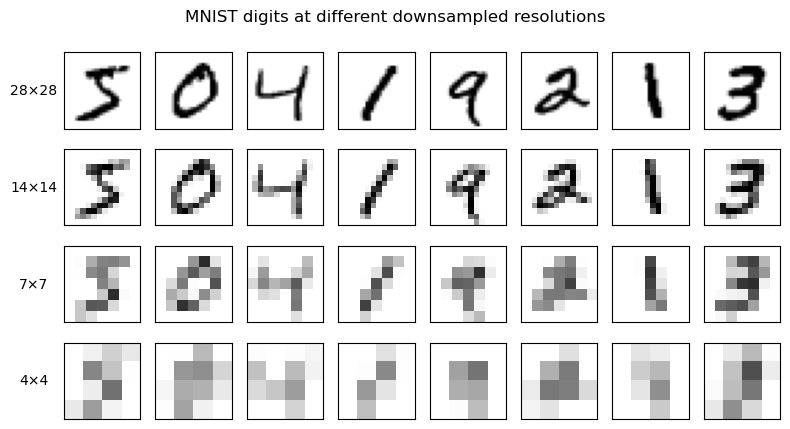

In [27]:
# --- Quick look: sample digits at different resolutions ---
resolutions = [28, 14, 7, 4]
fig, axes = plt.subplots(len(resolutions), 8, figsize=(8, len(resolutions) * 1.1))
for row, g in enumerate(resolutions):
    vecs = downsample_images(x_train[:8], g)
    for col in range(8):
        axes[row, col].imshow(vecs[col].reshape(g, g), cmap="gray_r", vmin=0, vmax=1)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
    axes[row, 0].set_ylabel(f"{g}×{g}", rotation=0, labelpad=22, va="center")
fig.suptitle("MNIST digits at different downsampled resolutions")
plt.tight_layout()
plt.show()

Training 28×28 inputs, 10 units, 50000 trials ...
  mean activity: 0.135 (target 0.125)
  active units / digit: 1.3
Training 14×14 inputs, 10 units, 50000 trials ...
  mean activity: 0.130 (target 0.125)
  active units / digit: 1.3
Training 7×7 inputs, 10 units, 50000 trials ...
  mean activity: 0.121 (target 0.125)
  active units / digit: 1.2
Training 4×4 inputs, 10 units, 50000 trials ...
  mean activity: 0.165 (target 0.125)
  active units / digit: 1.6

Resolution  Input dim  Mean act. Active/digit
------------------------------------------------------------------------
  28×28          784      0.135          1.3
  14×14          196      0.130          1.3
   7×7            49      0.121          1.2
   4×4            16      0.165          1.6


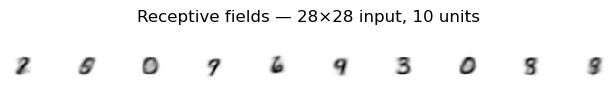

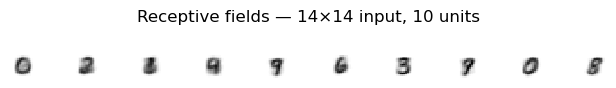

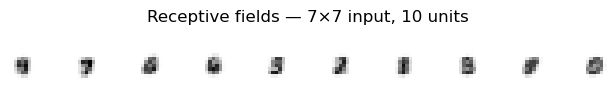

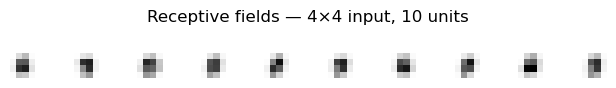

In [30]:
# ============================================================
# (a) Resolution sweep
# ============================================================

N_UNITS_FIXED = 10
resolution_results = {}

for g in [28, 14, 7, 4]:
    X_sub = downsample_images(x_train[:MNIST_TRAIN_SUBSET], g)
    cfg = make_mnist_cfg(g, N_UNITS_FIXED, n_trials=50000, seed=20 + g)
    resolution_results[g] = run_mnist_foldiak(X_sub, cfg)

print("\n" + "=" * 72)
print(f"{'Resolution':>10} {'Input dim':>10} {'Mean act.':>10} {'Active/digit':>12}")
print("-" * 72)
for g, res in resolution_results.items():
    sp = res["sparsity"]
    print(f"{g:>4}×{g:<4} {g*g:>10} {sp['mean_bit_activity']:>10.3f} {sp['active_units_per_sample']:>12.1f}")
print("=" * 72)

for g, res in resolution_results.items():
    plot_mnist_receptive_fields(res, title=f"Receptive fields — {g}×{g} input, {N_UNITS_FIXED} units")

Training 28×28 inputs, 5 units, 10000 trials ...
  mean activity: 0.201 (target 0.125)
  active units / digit: 1.0
Training 28×28 inputs, 10 units, 10000 trials ...
  mean activity: 0.158 (target 0.125)
  active units / digit: 1.6
Training 28×28 inputs, 20 units, 10000 trials ...
  mean activity: 0.139 (target 0.125)
  active units / digit: 2.8
Training 28×28 inputs, 40 units, 10000 trials ...
  mean activity: 0.121 (target 0.125)
  active units / digit: 4.8
Training 28×28 inputs, 80 units, 10000 trials ...
  mean activity: 0.091 (target 0.125)
  active units / digit: 7.3

   Units  Mean act.   Active/digit   Max active   Silent %
--------------------------------------------------------------------------------
       5      0.201            1.0            3      10.5
      10      0.158            1.6            5       1.8
      20      0.139            2.8            9       1.5
      40      0.121            4.8           18       7.0
      80      0.091            7.3           38 

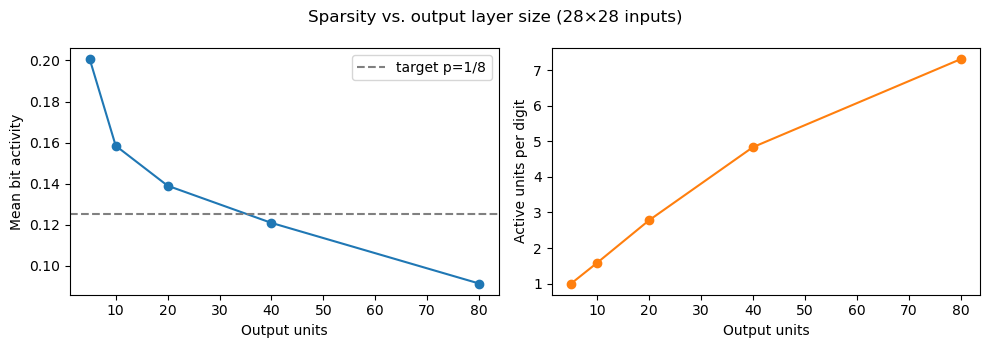

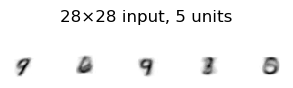

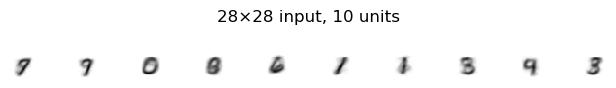

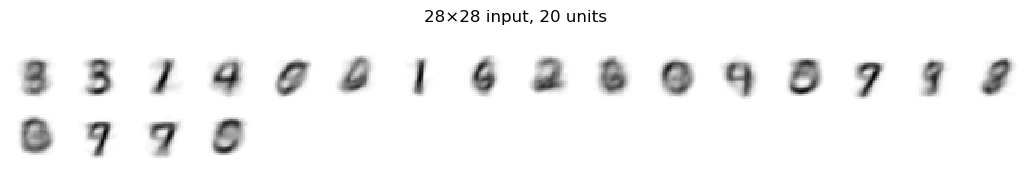

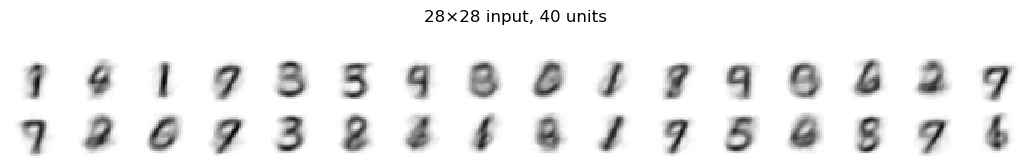

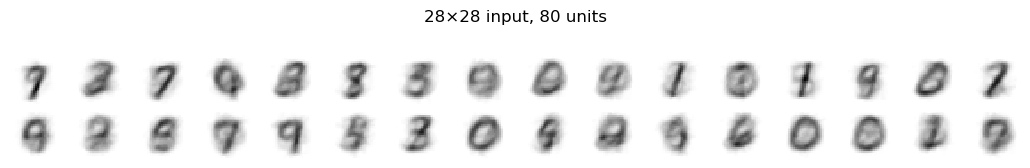

In [ ]:
# ============================================================
# (b) Output layer size sweep (fixed 14×14 inputs)
# ============================================================

GRID_FOR_UNITS = 28
X_mnist_14 = downsample_images(x_train[:MNIST_TRAIN_SUBSET], GRID_FOR_UNITS)
unit_sizes = [5, 10, 20, 40]
unit_results = {}

for n_units in unit_sizes:
    cfg = make_mnist_cfg(GRID_FOR_UNITS, n_units, n_trials=10000, seed=100 + n_units)
    unit_results[n_units] = run_mnist_foldiak(X_mnist_14, cfg)

print("\n" + "=" * 80)
print(f"{'Units':>8} {'Mean act.':>10} {'Active/digit':>14} {'Max active':>12} {'Silent %':>10}")
print("-" * 80)
for n_units, res in unit_results.items():
    sp = res["sparsity"]
    print(f"{n_units:>8} {sp['mean_bit_activity']:>10.3f} {sp['active_units_per_sample']:>14.1f} "
          f"{sp['max_active_units']:>12} {100*sp['fraction_silent_samples']:>9.1f}")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
units = list(unit_results.keys())
axes[0].plot(units, [unit_results[u]["sparsity"]["mean_bit_activity"] for u in units], "o-")
axes[0].axhline(Config().target_activity, color="gray", ls="--", label="target p=1/8")
axes[0].set_xlabel("Output units"); axes[0].set_ylabel("Mean bit activity"); axes[0].legend()
axes[1].plot(units, [unit_results[u]["sparsity"]["active_units_per_sample"] for u in units], "o-", color="C1")
axes[1].set_xlabel("Output units"); axes[1].set_ylabel("Active units per digit")
fig.suptitle(f"Sparsity vs. output layer size ({GRID_FOR_UNITS}×{GRID_FOR_UNITS} inputs)")
plt.tight_layout(); plt.show()

for n_units, res in unit_results.items():
    plot_mnist_receptive_fields(res, n_show=min(32, n_units),
                                title=f"{GRID_FOR_UNITS}×{GRID_FOR_UNITS} input, {n_units} units")

Training 28×28 inputs, 40 units, 10000 trials ...
  mean activity: 0.070 (target 0.025)
  active units / digit: 2.8

   Units  Mean act.   Active/digit   Max active   Silent %
--------------------------------------------------------------------------------
      40      0.070            2.8           10       0.9


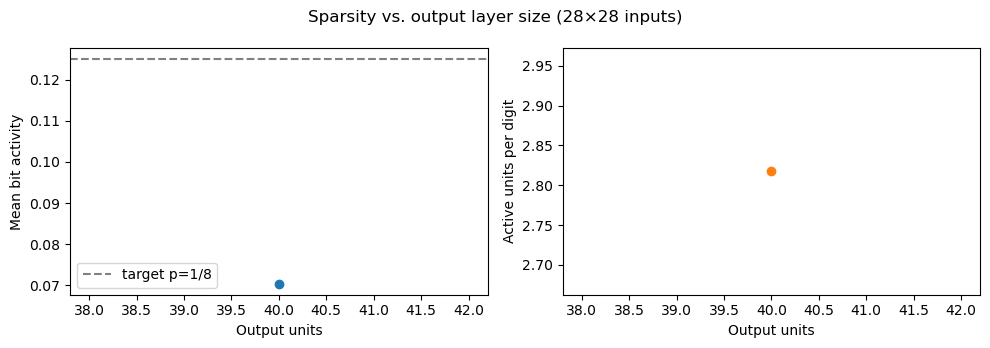

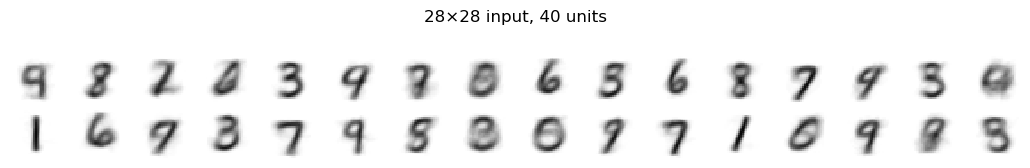

In [32]:
# ============================================================
# (b) Output layer size sweep (fixed 14×14 inputs)
# ============================================================

GRID_FOR_UNITS = 28
X_mnist_14 = downsample_images(x_train[:MNIST_TRAIN_SUBSET], GRID_FOR_UNITS)
unit_sizes = [40]
unit_results = {}

for n_units in unit_sizes:
    cfg = make_mnist_cfg(GRID_FOR_UNITS, n_units, n_trials=10000, seed=100 + n_units, target_activity=1/40)
    unit_results[n_units] = run_mnist_foldiak(X_mnist_14, cfg)

print("\n" + "=" * 80)
print(f"{'Units':>8} {'Mean act.':>10} {'Active/digit':>14} {'Max active':>12} {'Silent %':>10}")
print("-" * 80)
for n_units, res in unit_results.items():
    sp = res["sparsity"]
    print(f"{n_units:>8} {sp['mean_bit_activity']:>10.3f} {sp['active_units_per_sample']:>14.1f} "
          f"{sp['max_active_units']:>12} {100*sp['fraction_silent_samples']:>9.1f}")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
units = list(unit_results.keys())
axes[0].plot(units, [unit_results[u]["sparsity"]["mean_bit_activity"] for u in units], "o-")
axes[0].axhline(Config().target_activity, color="gray", ls="--", label="target p=1/8")
axes[0].set_xlabel("Output units"); axes[0].set_ylabel("Mean bit activity"); axes[0].legend()
axes[1].plot(units, [unit_results[u]["sparsity"]["active_units_per_sample"] for u in units], "o-", color="C1")
axes[1].set_xlabel("Output units"); axes[1].set_ylabel("Active units per digit")
fig.suptitle(f"Sparsity vs. output layer size ({GRID_FOR_UNITS}×{GRID_FOR_UNITS} inputs)")
plt.tight_layout(); plt.show()

for n_units, res in unit_results.items():
    plot_mnist_receptive_fields(res, n_show=min(32, n_units),
                                title=f"{GRID_FOR_UNITS}×{GRID_FOR_UNITS} input, {n_units} units")

Training 28×28 inputs, 16 units, 50000 trials ...
  mean activity: 0.140 (target 0.125)
  active units / digit: 2.2


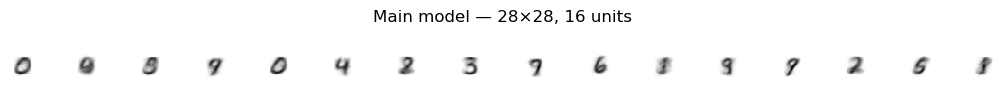


Linear classifier on raw 28×28 pixels (784 dims):
  train acc = 0.938,  test acc = 0.926
Linear classifier on Foldiak sparse codes (16 dims):
  train acc = 0.634,  test acc = 0.645

Condition       Raw dim  Code dim   Raw test  Sparse test  Active/dig
----------------------------------------------------------------------------------------
res 28×28           784        10      0.926        0.548         1.3
res 14×14           196        10      0.924        0.528         1.3
res 7×7              49        10      0.895        0.501         1.2
res 4×4              16        10      0.745        0.361         1.6
units=40            784        40      0.926        0.755         2.8


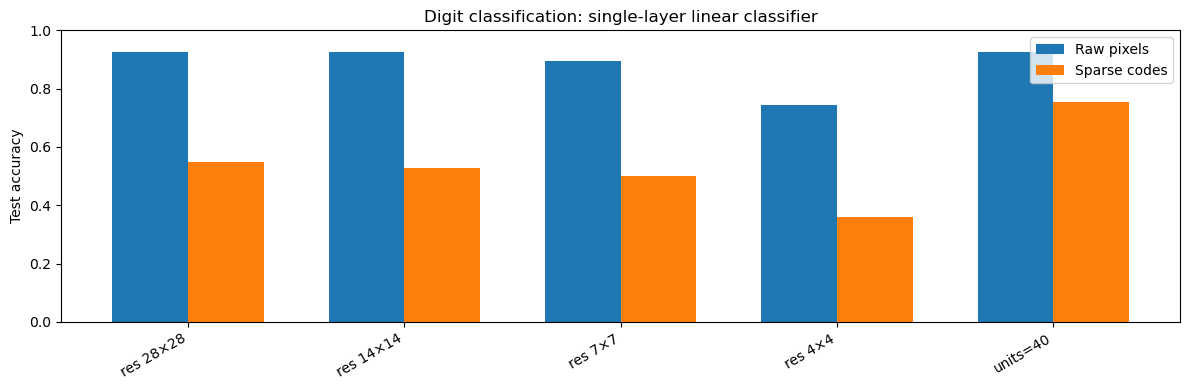

In [35]:
# ============================================================
# (c) Downstream digit classification: sparse codes vs. raw pixels
# ============================================================

# Train one main Foldiak model (14×14, 32 units) with full trial budget
GRID_CLS = 28
UNITS_CLS = 16
X_tr = downsample_images(x_train[:MNIST_TRAIN_SUBSET], GRID_CLS)
X_te = downsample_images(x_test, GRID_CLS)

cls_result = run_mnist_foldiak(
    X_tr,
    make_mnist_cfg(GRID_CLS, UNITS_CLS, n_trials=MNIST_N_TRIALS, seed=42),
)
plot_mnist_receptive_fields(cls_result, title=f"Main model — {GRID_CLS}×{GRID_CLS}, {UNITS_CLS} units")

Y_tr = encode_dataset(cls_result["model"], X_tr)
Y_te = encode_dataset(cls_result["model"], X_te)

raw_train_acc, raw_test_acc = train_linear_classifier(X_tr, y_train[:MNIST_TRAIN_SUBSET], X_te, y_test)
sparse_train_acc, sparse_test_acc = train_linear_classifier(Y_tr, y_train[:MNIST_TRAIN_SUBSET], Y_te, y_test)

print(f"\nLinear classifier on raw {GRID_CLS}×{GRID_CLS} pixels ({X_tr.shape[1]} dims):")
print(f"  train acc = {raw_train_acc:.3f},  test acc = {raw_test_acc:.3f}")
print(f"Linear classifier on Foldiak sparse codes ({UNITS_CLS} dims):")
print(f"  train acc = {sparse_train_acc:.3f},  test acc = {sparse_test_acc:.3f}")

# Also compare across resolutions / unit counts from sweeps above
comparison_rows = []

for g, res in resolution_results.items():
    Xtr = downsample_images(x_train[:MNIST_TRAIN_SUBSET], g)
    Xte = downsample_images(x_test, g)
    Ytr = encode_dataset(res["model"], Xtr)
    Yte = encode_dataset(res["model"], Xte)
    _, raw_acc = train_linear_classifier(Xtr, y_train[:MNIST_TRAIN_SUBSET], Xte, y_test)
    _, sparse_acc = train_linear_classifier(Ytr, y_train[:MNIST_TRAIN_SUBSET], Yte, y_test)
    comparison_rows.append((f"res {g}×{g}", g * g, N_UNITS_FIXED, raw_acc, sparse_acc,
                            res["sparsity"]["active_units_per_sample"]))

for n_units, res in unit_results.items():
    Ytr = encode_dataset(res["model"], X_mnist_14)
    Yte = encode_dataset(res["model"], downsample_images(x_test, GRID_FOR_UNITS))
    _, raw_acc = train_linear_classifier(X_mnist_14, y_train[:MNIST_TRAIN_SUBSET],
                                         downsample_images(x_test, GRID_FOR_UNITS), y_test)
    _, sparse_acc = train_linear_classifier(Ytr, y_train[:MNIST_TRAIN_SUBSET], Yte, y_test)
    comparison_rows.append((f"units={n_units}", GRID_FOR_UNITS ** 2, n_units, raw_acc, sparse_acc,
                            res["sparsity"]["active_units_per_sample"]))

print("\n" + "=" * 88)
print(f"{'Condition':<14} {'Raw dim':>8} {'Code dim':>9} {'Raw test':>10} {'Sparse test':>12} {'Active/dig':>11}")
print("-" * 88)
for label, raw_dim, code_dim, raw_acc, sparse_acc, active in comparison_rows:
    print(f"{label:<14} {raw_dim:>8} {code_dim:>9} {raw_acc:>10.3f} {sparse_acc:>12.3f} {active:>11.1f}")
print("=" * 88)

labels = [r[0] for r in comparison_rows]
raw_accs = [r[3] for r in comparison_rows]
sparse_accs = [r[4] for r in comparison_rows]
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width/2, raw_accs, width, label="Raw pixels")
ax.bar(x + width/2, sparse_accs, width, label="Sparse codes")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("Test accuracy"); ax.set_ylim(0, 1)
ax.legend(); ax.set_title("Digit classification: single-layer linear classifier")
plt.tight_layout(); plt.show()

In [36]:
# 80 units @ 28×28

GRID = 28
N_UNITS = 80
N_TRIALS = 50000  

X_tr = downsample_images(x_train[:MNIST_TRAIN_SUBSET], GRID)
X_te = downsample_images(x_test, GRID)

res_80 = run_mnist_foldiak(
    X_tr,
    make_mnist_cfg(GRID, N_UNITS, n_trials=N_TRIALS, seed=180),
)
print(f"Sparsity: mean activity={res_80['sparsity']['mean_bit_activity']:.3f}, "
      f"active/digit={res_80['sparsity']['active_units_per_sample']:.1f}")

Y_tr = encode_dataset(res_80["model"], X_tr)
Y_te = encode_dataset(res_80["model"], X_te)

raw_train, raw_test = train_linear_classifier(X_tr, y_train[:MNIST_TRAIN_SUBSET], X_te, y_test)
sparse_train, sparse_test = train_linear_classifier(Y_tr, y_train[:MNIST_TRAIN_SUBSET], Y_te, y_test)

print(f"\n28×28 raw pixels ({X_tr.shape[1]} dims): train={raw_train:.3f}, test={raw_test:.3f}")
print(f"Foldiak sparse codes ({N_UNITS} dims):     train={sparse_train:.3f}, test={sparse_test:.3f}")


Training 28×28 inputs, 80 units, 50000 trials ...
  mean activity: 0.088 (target 0.125)
  active units / digit: 7.0
Sparsity: mean activity=0.088, active/digit=7.0

28×28 raw pixels (784 dims): train=0.938, test=0.926
Foldiak sparse codes (80 dims):     train=0.613, test=0.613


# Chinese characters (Hanzi) — HSK-1 handwriting


In [91]:
# ============================================================
# 8. HSK-1 Hanzi — download (cached) and load
# ============================================================
# ~226 MB on Kaggle; 178 HSK-1 characters. Cached under ~/.cache/kagglehub/.
# Optional: HANZI_DATA_ROOT = Path("...") or env var before running.

try:
    import kagglehub
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub", "-q"])
    import kagglehub

import os
from pathlib import Path
from PIL import Image

HSK1_DATASET = "vitaliikyzym/chinese-handwriting-recognition-hsk-1"

if "HANZI_DATA_ROOT" not in globals():
    env_root = os.environ.get("HANZI_DATA_ROOT")
    if env_root and Path(env_root).exists():
        HANZI_DATA_ROOT = Path(env_root)
        print("Using HANZI_DATA_ROOT from environment:", HANZI_DATA_ROOT.resolve())
    else:
        # dataset_download uses ~/.cache/kagglehub after the first run (no re-download)
        print("Resolving HSK-1 path via kagglehub (downloads ~226 MB only once) ...")
        HANZI_DATA_ROOT = Path(kagglehub.dataset_download(HSK1_DATASET))
print("Path to dataset files:", HANZI_DATA_ROOT.resolve())

# Subset knobs (dataset has 178 classes total)
HANZI_MAX_CLASSES = 30        # None = use all 178; or set e.g. 48 for a faster run
HANZI_SAMPLES_PER_CLASS = 30    # max images per character
HANZI_TRAIN_FRACTION = 0.85     # hold out within subset for classifier eval
HANZI_GRID = 16
HANZI_N_UNITS = 50              # whole-char + patch experiments (matched)
HANZI_N_TRIALS = 10000
HANZI_SEED = 99
HANZI_ALPHA = 0.25              # shared anti-Hebbian rate
HANZI_GAMMA = 0.06              # shared threshold learning rate
HANZI_TARGET_ACTIVITY = 1 / 40    # shared p_target for both experiments

# Section 8b: random PATCH_SIZE crops from native-resolution PNGs
HANZI_LOAD_SIZE = None      # None = native PNG; int (e.g. 64) = resize all
PATCH_SIZE = 16             # 16×16 crops → Foldiak input
PATCH_PER_IMAGE = 50
PATCH_N_UNITS = HANZI_N_UNITS
PATCH_N_TRIALS = HANZI_N_TRIALS
PATCH_MIN_INK = 0.04

def _find_hsk_image_root(root: Path) -> Path:
    """Folder-per-character tree: …/CASIA-HWDB_Test/Test/<character>/*.png"""
    root = Path(root)
    candidates = [
        root / "chinese-handwriting" / "CASIA-HWDB_Test" / "Test",
        root / "CASIA-HWDB_Test" / "Test",
    ]
    for p in candidates:
        if p.is_dir() and any(c.is_dir() for c in p.iterdir()):
            return p
    for p in root.rglob("Test"):
        if p.is_dir() and p.parent.name == "CASIA-HWDB_Test":
            if any(c.is_dir() for c in p.iterdir()):
                return p
    raise FileNotFoundError(f"Could not find HSK-1 image folders under {root}")


def resize_char_images(images, grid_size: int):
    """Resize (N, H, W) uint8/float arrays — or a list of (H, W) — to grid_size² flat vectors in [0, 1]."""
    if isinstance(images, list):
        n = len(images)
        out = np.zeros((n, grid_size, grid_size), dtype=float)
        for i in range(n):
            im = Image.fromarray(images[i].astype(np.uint8))
            im = im.resize((grid_size, grid_size), Image.Resampling.LANCZOS)
            out[i] = np.asarray(im, dtype=float)
        return (out.reshape(n, -1) / 255.0)
    images = np.asarray(images)
    n = images.shape[0]
    out = np.zeros((n, grid_size, grid_size), dtype=float)
    for i in range(n):
        im = Image.fromarray(images[i].astype(np.uint8))
        im = im.resize((grid_size, grid_size), Image.Resampling.LANCZOS)
        out[i] = np.asarray(im, dtype=float)
    return (out.reshape(n, -1) / 255.0)


def load_hanzi_subset(
    root,
    max_classes=HANZI_MAX_CLASSES,
    samples_per_class=HANZI_SAMPLES_PER_CLASS,
    load_size=HANZI_LOAD_SIZE,
    seed=HANZI_SEED,
):
    """Load PNGs from HSK-1 class subfolders (UTF-8 character names).

    Images vary in pixel size; each is resized to load_size×load_size (default 64×64 for patch crops).
    Whole-character Foldiak still downsamples separately to HANZI_GRID.
    """
    split_dir = _find_hsk_image_root(Path(root))
    rng = np.random.default_rng(seed)

    class_dirs = sorted([p for p in split_dir.iterdir() if p.is_dir()])
    if max_classes is not None and len(class_dirs) > max_classes:
        class_dirs = list(rng.choice(class_dirs, size=max_classes, replace=False))
        class_dirs.sort(key=lambda p: p.name)

    images, labels, label_names = [], [], []
    for cls_dir in class_dirs:
        pngs = sorted(cls_dir.glob("*.png"))
        if not pngs:
            continue
        cls_idx = len(label_names)
        label_names.append(cls_dir.name)
        if len(pngs) > samples_per_class:
            pngs = list(rng.choice(pngs, size=samples_per_class, replace=False))
            pngs.sort()
        for path in pngs:
            im = Image.open(path).convert("L")
            arr = np.asarray(im, dtype=np.uint8)
            if load_size is not None:
                im = Image.fromarray(arr).resize(
                    (load_size, load_size), Image.Resampling.LANCZOS
                )
                arr = np.asarray(im, dtype=np.uint8)
            images.append(arr)
            labels.append(cls_idx)

    y = np.asarray(labels, dtype=int)
    if load_size is not None:
        X = np.stack(images, axis=0)
    else:
        X = images
    return X, y, label_names, split_dir


def train_test_split_hanzi(X, y, train_fraction=0.9, seed=0):
    rng = np.random.default_rng(seed)
    train_idx, test_idx = [], []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        rng.shuffle(idx)
        n_train = max(1, int(round(train_fraction * len(idx))))
        train_idx.extend(idx[:n_train])
        test_idx.extend(idx[n_train:])
    return np.array(train_idx), np.array(test_idx)


def sample_hanzi_patches(
    images,
    patch_size=PATCH_SIZE,
    patches_per_image=PATCH_PER_IMAGE,
    min_ink=PATCH_MIN_INK,
    seed=HANZI_SEED,
):
    """Random patch_size×patch_size crops from (N, H, W) uint8 images → (M, patch_size²) in [0, 1].

    Pass list of native (H,W) images or stacked (N,H,W). patch_size is only the crop window.
    """
    rng = np.random.default_rng(seed)
    ps = int(patch_size)
    if isinstance(images, list):
        image_list = [np.asarray(im) for im in images]
    else:
        images = np.asarray(images)
        image_list = [images[i] for i in range(images.shape[0])]
    patches = []
    for img_u8 in image_list:
        img = img_u8.astype(float)
        if img.max() > 1.0:
            img = img / 255.0
        h, w = img.shape
        if h < ps or w < ps:
            raise ValueError(f"Image {h}×{w} smaller than patch {ps}×{ps}")
        for _ in range(patches_per_image):
            for attempt in range(30):
                r0 = int(rng.integers(0, h - ps + 1))
                c0 = int(rng.integers(0, w - ps + 1))
                patch = img[r0 : r0 + ps, c0 : c0 + ps]
                if patch.mean() >= min_ink or attempt == 29:
                    patches.append(patch.reshape(-1))
                    break
    return np.stack(patches, axis=0).astype(float)


# Load HSK-1 subset and resize (unsupervised train / held-out eval within subset)
X_hanzi_native, y_hanzi, hanzi_labels, hanzi_image_dir = load_hanzi_subset(
    HANZI_DATA_ROOT, load_size=HANZI_LOAD_SIZE
)
train_idx, test_idx = train_test_split_hanzi(
    X_hanzi_native, y_hanzi, train_fraction=HANZI_TRAIN_FRACTION, seed=HANZI_SEED
)

X_hanzi = resize_char_images(X_hanzi_native, HANZI_GRID)
X_tr_h = X_hanzi[train_idx]
X_te_h = X_hanzi[test_idx]
y_tr_h = y_hanzi[train_idx]
y_te_h = y_hanzi[test_idx]

print(f"Image dir: {hanzi_image_dir}")
print(f"Classes loaded: {len(hanzi_labels)}  (e.g. {hanzi_labels[:8]} …)")
print(f"Samples: {len(y_hanzi)} total → train {len(train_idx)}, test {len(test_idx)}")
print(f"Whole-char Foldiak: {HANZI_GRID}×{HANZI_GRID} ({X_tr_h.shape[1]} dims)")
if isinstance(X_hanzi_native, list):
    hs, ws = zip(*[im.shape for im in X_hanzi_native])
    print(f"Patch source: native PNGs H∈[{min(hs)},{max(hs)}] W∈[{min(ws)},{max(ws)}] → {PATCH_SIZE}×{PATCH_SIZE} crops")
else:
    print(f"Patch source: {X_hanzi_native.shape[1]}×{X_hanzi_native.shape[2]} → {PATCH_SIZE}×{PATCH_SIZE} crops")


Path to dataset files: /resnick/home/fyu2/.cache/kagglehub/datasets/vitaliikyzym/chinese-handwriting-recognition-hsk-1/versions/1
Image dir: /home/fyu2/.cache/kagglehub/datasets/vitaliikyzym/chinese-handwriting-recognition-hsk-1/versions/1/chinese-handwriting/CASIA-HWDB_Test/Test
Classes loaded: 30  (e.g. ['µñà', 'µ░┤', 'Θú₧', 'Σ║å', 'Σ║ö', 'Σ║║', 'Σ╕£', 'Σ╕Ç'] …)
Samples: 900 total → train 780, test 120
Whole-char Foldiak: 16×16 (256 dims)
Patch source: native PNGs H∈[24,150] W∈[24,150] → 16×16 crops


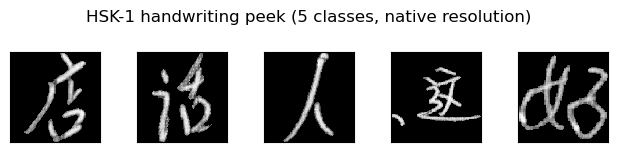

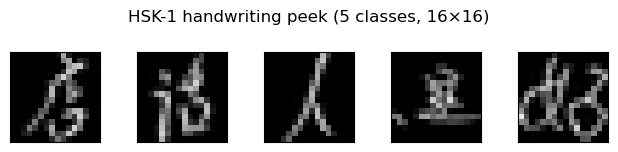

Whole-char Foldiak input: 16×16 (256 pixels)


In [105]:
# --- HSK-1: quick peek + train Foldiak ---

def peek_hanzi_dataset(X_flat, y, label_names, n_show=5, grid_size=HANZI_GRID, seed=0):
    """Show one random example from each of n_show character classes."""
    rng = np.random.default_rng(seed)
    classes = np.unique(y)
    n_show = min(n_show, len(classes))
    pick_cls = rng.choice(classes, size=n_show, replace=False)

    fig, axes = plt.subplots(1, n_show, figsize=(n_show * 1.3, 1.5))
    axes = np.atleast_1d(axes)
    for ax, cls in zip(axes, pick_cls):
        idx = np.where(y == cls)[0]
        i = rng.choice(idx)
        raw = X_flat[i]
        if isinstance(raw, np.ndarray) and raw.ndim == 2:
            img = raw.astype(float)
        else:
            img = np.asarray(raw.reshape(grid_size, grid_size), dtype=float)
        if img.max() > 1.0:
            img = img / 255.0
        ax.imshow(img, cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
        # ax.set_title(label_names[cls], fontsize=13)
        ax.set_xticks([]); ax.set_yticks([])
    native = isinstance(X_flat[0], np.ndarray) and np.asarray(X_flat[0]).ndim == 2
    res_note = "native resolution" if native else f"{grid_size}×{grid_size}"
    fig.suptitle(f"HSK-1 handwriting peek ({n_show} classes, {res_note})")
    plt.tight_layout()
    plt.show()


# Peek: same 5 random classes at native vs 16×16 (whole-char Foldiak input)
_peek_seed = HANZI_SEED
_peek_X = [X_hanzi_native[i] for i in train_idx]
peek_hanzi_dataset(_peek_X, y_tr_h, hanzi_labels, n_show=5, seed=_peek_seed)
peek_hanzi_dataset(
    X_tr_h, y_tr_h, hanzi_labels, n_show=5, grid_size=HANZI_GRID, seed=_peek_seed
)
print(f"Whole-char Foldiak input: {HANZI_GRID}×{HANZI_GRID} ({X_tr_h.shape[1]} pixels)")



Hanzi cfg: alpha=0.25, gamma=0.03, p=0.025
Training 16×16 inputs, 50 units, 50000 trials ...
  mean activity: 0.010 (target 0.025)
  active units / digit: 0.5
Per-unit ON rate: min=0.000 max=0.032 std=0.008 | dominant unit 39 @ 3.2%


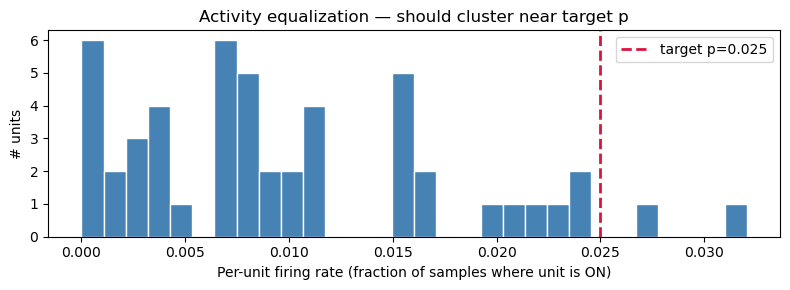

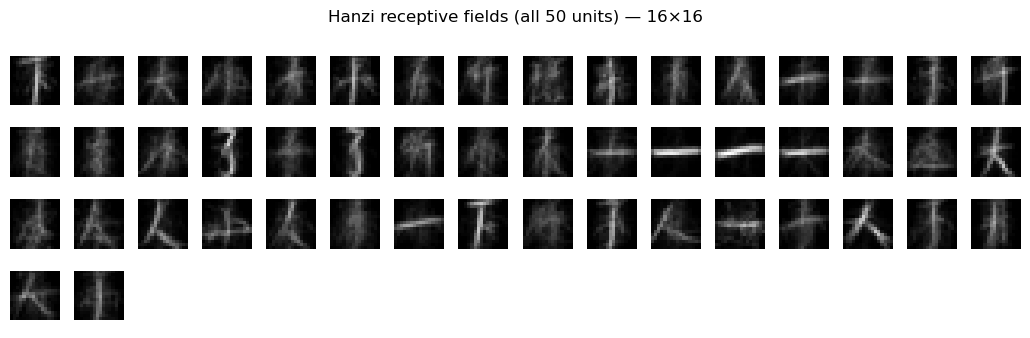

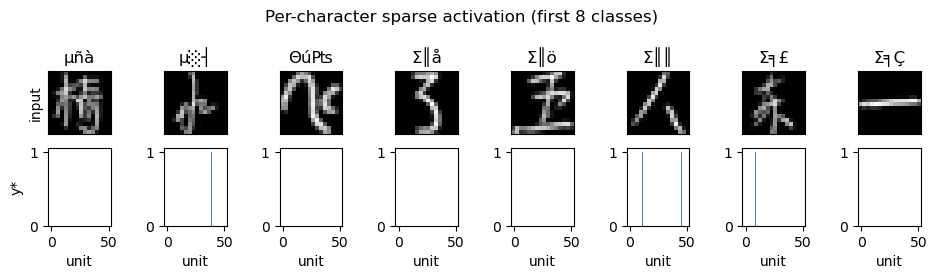

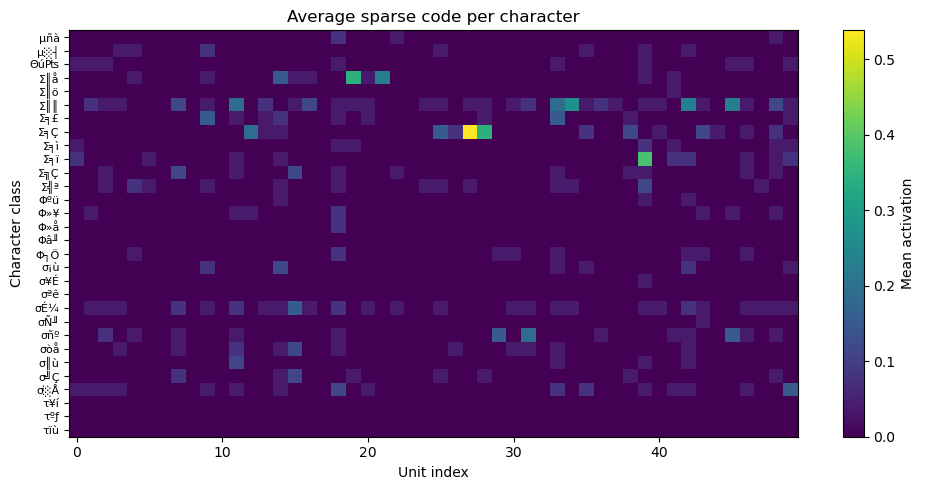

In [106]:

# HANZI_ALPHA / HANZI_GAMMA set in load cell
hanzi_cfg = make_mnist_cfg(
    HANZI_GRID,
    HANZI_N_UNITS,
    n_trials=HANZI_N_TRIALS,
    seed=HANZI_SEED,
    alpha=HANZI_ALPHA,
    gamma=HANZI_GAMMA,
    target_activity=HANZI_TARGET_ACTIVITY,
)
print(f"Hanzi cfg: alpha={hanzi_cfg.alpha}, gamma={hanzi_cfg.gamma}, p={hanzi_cfg.target_activity:.3f}")

hanzi_result = run_mnist_foldiak(X_tr_h, hanzi_cfg)

# Activity equalization check
sp_h = measure_sparsity(hanzi_result["model"], X_tr_h, seed=HANZI_SEED)
rates = sp_h["per_unit_rate"]
p_tgt = sp_h["target_activity"]
dominant = int(np.argmax(rates))
print(
    f"Per-unit ON rate: min={rates.min():.3f} max={rates.max():.3f} "
    f"std={rates.std():.3f} | dominant unit {dominant} @ {rates[dominant]:.1%}"
)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(rates, bins=min(30, HANZI_N_UNITS), color="steelblue", edgecolor="white")
ax.axvline(p_tgt, color="crimson", ls="--", lw=2, label=f"target p={p_tgt:.3f}")
ax.set_xlabel("Per-unit firing rate (fraction of samples where unit is ON)")
ax.set_ylabel("# units")
ax.set_title("Activity equalization — should cluster near target p")
ax.legend()
plt.tight_layout()
plt.show()

if rates.max() > 3 * p_tgt or rates.std() > 2 * p_tgt:
    print(
        "Rates still uneven → try HANZI_GAMMA=0.08–0.10 and/or HANZI_ALPHA=0.3–0.4, then re-run."
    )

plot_mnist_receptive_fields(
    hanzi_result,
    n_show=HANZI_N_UNITS,
    title=f"Hanzi receptive fields (all {HANZI_N_UNITS} units) — {HANZI_GRID}×{HANZI_GRID}",
)

# Per-character sparse codes (which units fire?)
n_show_cls = min(8, len(hanzi_labels))
fig, axes = plt.subplots(2, n_show_cls, figsize=(n_show_cls * 1.2, 2.8))
for col, cls in enumerate(range(n_show_cls)):
    idx = np.where(y_tr_h == cls)[0][:1]
    if len(idx) == 0:
        continue
    _, y_act = hanzi_result["model"].settle(X_tr_h[idx[0]])
    axes[0, col].imshow(
        X_tr_h[idx[0]].reshape(HANZI_GRID, HANZI_GRID), cmap="gray_r", vmin=0, vmax=1
    )
    axes[0, col].set_title(hanzi_labels[cls], fontsize=12)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])
    axes[1, col].bar(np.arange(len(y_act)), y_act, color="steelblue", width=0.8)
    axes[1, col].set_ylim(0, 1.05)
    axes[1, col].set_xlabel("unit")
axes[0, 0].set_ylabel("input")
axes[1, 0].set_ylabel("y*")
fig.suptitle("Per-character sparse activation (first 8 classes)")
plt.tight_layout()
plt.show()

mean_codes = np.zeros((len(hanzi_labels), HANZI_N_UNITS))
for cls in range(len(hanzi_labels)):
    idx = np.where(y_tr_h == cls)[0]
    mean_codes[cls] = encode_dataset(hanzi_result["model"], X_tr_h[idx]).mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(mean_codes, aspect="auto", cmap="viridis", vmin=0, vmax=mean_codes.max() or 1)
ax.set_xlabel("Unit index")
ax.set_ylabel("Character class")
ax.set_yticks(range(len(hanzi_labels)))
ax.set_yticklabels(hanzi_labels, fontsize=8)
plt.colorbar(im, ax=ax, label="Mean activation")
ax.set_title("Average sparse code per character")
plt.tight_layout()
plt.show()

## Hanzi stroke patches — random crops from 64×64 images




Patch dataset: 39000 patches (50/image × 780 images), 16×16 = 256 dims


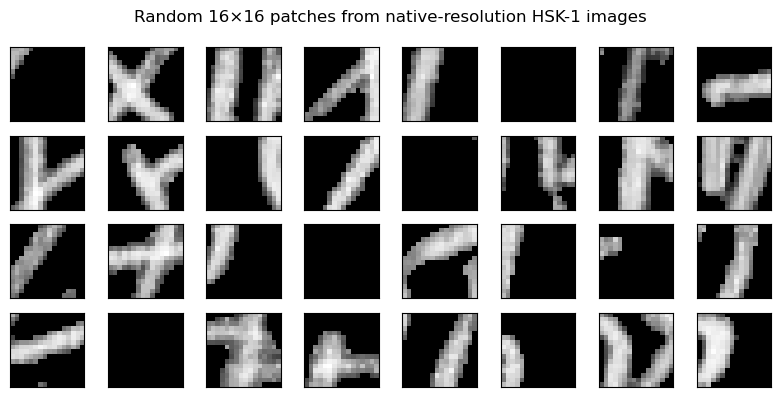

Patch cfg: alpha=0.25, gamma=0.03, p=0.025
Training 16×16 inputs, 50 units, 50000 trials ...
  mean activity: 0.011 (target 0.025)
  active units / digit: 0.6
Per-unit ON rate: min=0.001 max=0.042 std=0.010 | dominant unit 14 @ 4.2%


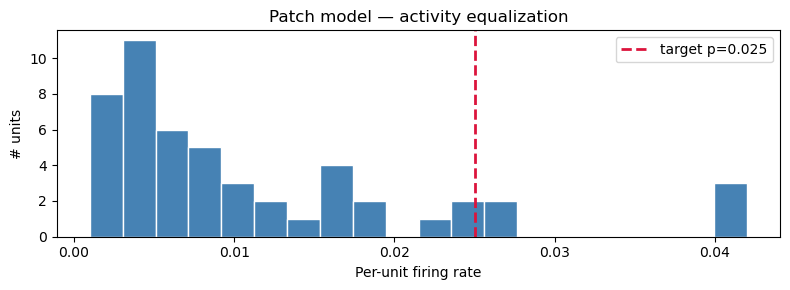

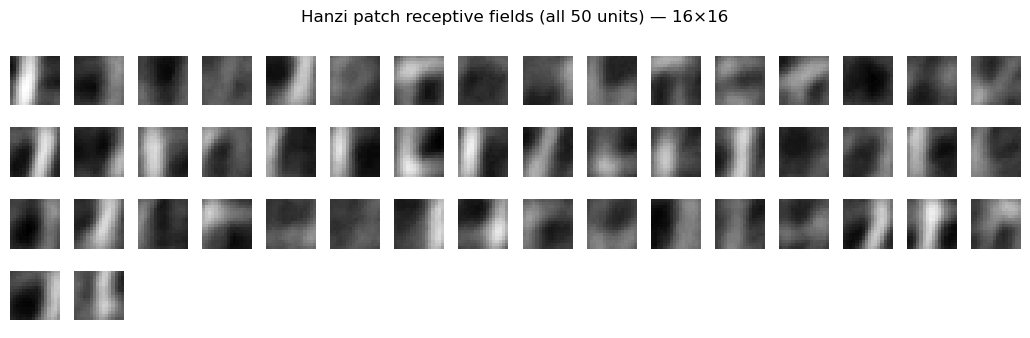

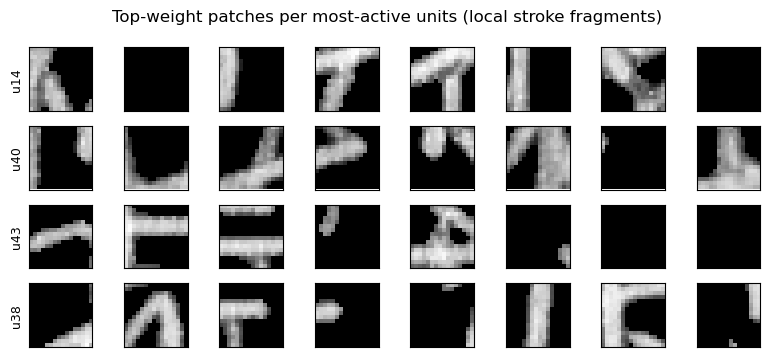

In [107]:
# --- 8b: random patches from native HSK-1 training images ---
assert "X_hanzi_native" in globals() and "train_idx" in globals(), (
    "Run the HSK-1 load cell first."
)

X_tr_p = sample_hanzi_patches(
    [X_hanzi_native[i] for i in train_idx],
    patch_size=PATCH_SIZE,
    patches_per_image=PATCH_PER_IMAGE,
    min_ink=PATCH_MIN_INK,
    seed=HANZI_SEED + 7,
)
print(
    f"Patch dataset: {X_tr_p.shape[0]} patches "
    f"({PATCH_PER_IMAGE}/image × {len(train_idx)} images), "
    f"{PATCH_SIZE}×{PATCH_SIZE} = {X_tr_p.shape[1]} dims"
)

# Peek: random patch examples (inputs to Foldiak)
rng_p = np.random.default_rng(HANZI_SEED + 8)
n_peek = 32
peek_idx = rng_p.choice(len(X_tr_p), size=n_peek, replace=False)
fig, axes = plt.subplots(4, 8, figsize=(8, 4))
for ax, i in zip(axes.flatten(), peek_idx):
    ax.imshow(
        X_tr_p[i].reshape(PATCH_SIZE, PATCH_SIZE),
        cmap="gray_r", vmin=0, vmax=1, interpolation="nearest",
    )
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Random {PATCH_SIZE}×{PATCH_SIZE} patches from native-resolution HSK-1 images")
plt.tight_layout()
plt.show()

# Same tuning knobs as whole-character Hanzi cell
patch_cfg = make_mnist_cfg(
    PATCH_SIZE,
    PATCH_N_UNITS,
    n_trials=PATCH_N_TRIALS,
    seed=HANZI_SEED + 20,
    alpha=HANZI_ALPHA,
    gamma=HANZI_GAMMA,
    target_activity=HANZI_TARGET_ACTIVITY,
)
print(f"Patch cfg: alpha={patch_cfg.alpha}, gamma={patch_cfg.gamma}, p={patch_cfg.target_activity:.3f}")

patch_result = run_mnist_foldiak(X_tr_p, patch_cfg)

sp_p = measure_sparsity(patch_result["model"], X_tr_p, seed=HANZI_SEED + 21)
rates_p = sp_p["per_unit_rate"]
p_tgt_p = sp_p["target_activity"]
dom_p = int(np.argmax(rates_p))
print(
    f"Per-unit ON rate: min={rates_p.min():.3f} max={rates_p.max():.3f} "
    f"std={rates_p.std():.3f} | dominant unit {dom_p} @ {rates_p[dom_p]:.1%}"
)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(rates_p, bins=min(20, PATCH_N_UNITS), color="steelblue", edgecolor="white")
ax.axvline(p_tgt_p, color="crimson", ls="--", lw=2, label=f"target p={p_tgt_p:.3f}")
ax.set_xlabel("Per-unit firing rate")
ax.set_ylabel("# units")
ax.set_title("Patch model — activity equalization")
ax.legend()
plt.tight_layout()
plt.show()

plot_mnist_receptive_fields(
    patch_result,
    n_show=PATCH_N_UNITS,
    title=f"Hanzi patch receptive fields (all {PATCH_N_UNITS} units) — {PATCH_SIZE}×{PATCH_SIZE}",
)

# Which patch types drive each unit? (strongest Q weights)
model_p = patch_result["model"]
n_top = min(4, PATCH_N_UNITS)
top_units = np.argsort(rates_p)[-n_top:][::-1]
fig, axes = plt.subplots(n_top, 8, figsize=(8, n_top * 0.9))
if n_top == 1:
    axes = np.atleast_2d(axes)
for row, ui in enumerate(top_units):
    w = model_p.Q[ui]
    patch_idx = np.argsort(w)[-8:][::-1]
    for col, pi in enumerate(patch_idx):
        ax = axes[row, col]
        ax.imshow(
            X_tr_p[pi].reshape(PATCH_SIZE, PATCH_SIZE),
            cmap="gray_r", vmin=0, vmax=1, interpolation="nearest",
        )
        ax.set_xticks([]); ax.set_yticks([])
    axes[row, 0].set_ylabel(f"u{ui}", fontsize=9)
fig.suptitle("Top-weight patches per most-active units (local stroke fragments)")
plt.tight_layout()
plt.show()

